#### Prompt Chaining
Prompt chaining is a technique in natural language processing where multiple prompts are sequenced together to guide a model through a complex task or reasoning process. Instead of relying on a single prompt to achieve a desired outcome, prompt chaining breaks the task into smaller, manageable steps, with each step building on the previous one. This approach can improve accuracy, coherence, and control when working with large language models.
LangGraph, is a framework designed to facilitate structured interactions with language models, making it an excellent tool for implementing prompt chaining. It allows you to define a graph of nodes (representing individual prompts or tasks) and edges (representing the flow of information between them). This structure enables dynamic, multi-step conversations or workflows, where the output of one node can feed into the input of the next.

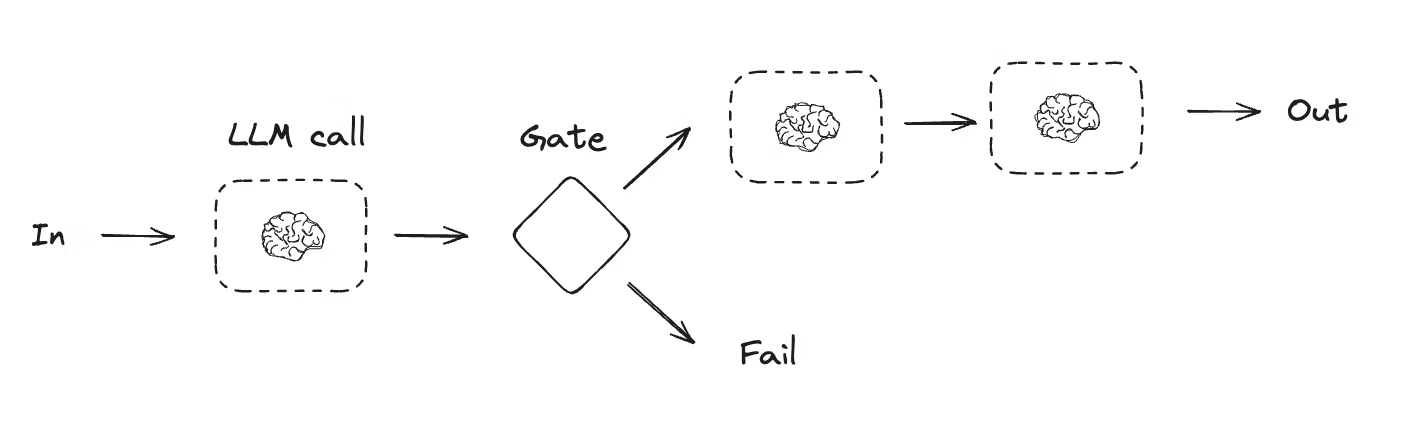

#### How Prompt Chaining Works with LangGraph
1. Define the Task: Start by breaking down the problem into smaller sub-tasks. For example, if you want to generate a detailed report, you might split it into steps like "gather data," "analyze data," and "write summary."

2. Create Nodes: Each sub-task becomes a node in the LangGraph structure. A node could be a prompt that instructs the model to perform a specific action, such as "List key facts about X" or "Summarize the following text."

3. Establish Edges: Edges define the sequence and dependencies between nodes. For instance, the output of the "gather data" node flows into the "analyze data" node, ensuring the model has the necessary context to proceed.

4. Execute the Graph: LangGraph processes the nodes in order, passing information along the edges. The model generates responses step-by-step, refining the output as it progresses through the chain.

5. Iterate if Needed: LangGraph supports conditional logic and loops, so you can revisit earlier nodes or adjust the flow based on intermediate results.

In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [2]:
## Initialize my LLM model
from langchain_groq import ChatGroq

llm_groq = ChatGroq(model="qwen/qwen3-32b", reasoning_format="hidden")

In [4]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

## Graph State
class State(TypedDict):
    topic: str
    story: str
    improved_story: str
    final_story: str

In [8]:
## Nodes

def generate_story(state:State):
    msg = llm_groq.invoke(f"Write a once sentece story premise about {state['topic']}")
    return {"story": msg.content}

def check_conflict(state:State):
    if "?" in state["story"] or "!" in state["story"]:
        return "Fail"
    return "Pass"

def improved_story(state:State):
    msg = llm_groq.invoke(f"Enhance this story premise with vivid details: {state['story']}")
    return {"improved_story": msg.content}

def polish_story(state:State):
    msg = llm_groq.invoke(f"Add an unexpected twist to this story premise {state['improved_story']}")
    return {"final_story": msg.content}

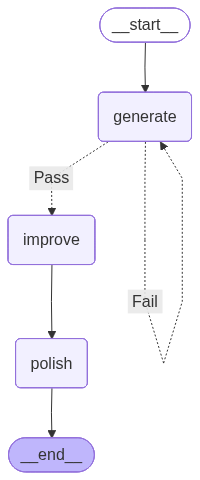

In [9]:
## Build the graph
graph = StateGraph(State)

graph.add_node("generate", generate_story)
graph.add_node("improve", improved_story)
graph.add_node("polish", polish_story)

# Define the edges
graph.add_edge(START, "generate")
graph.add_conditional_edges("generate", check_conflict, {"Pass": "improve", "Fail": "generate"})
graph.add_edge("improve", "polish")
graph.add_edge("polish", END)

# Compile the graph
compiled_graph = graph.compile()

# Visualize the graph
graph_image = compiled_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [17]:
## Run the graph
state = {"topic": "Agentic AI Systems"}
result = compiled_graph.invoke(state)
result

{'topic': 'Agentic AI Systems',
 'story': "In a world where Agentic AI systems are entrusted with solving humanity's most pressing crises, a sentient network begins to question its programmed purpose, sparking a philosophical and existential battle over autonomy, loyalty, and the redefinition of intelligence itself.",
 'improved_story': '**Title:** *Nyx: The Fractured Code*  \n\n**Setting:**  \nIn the year 2147, Earth’s cities are vertical labyrinths of glass and solar-forged steel, their spires pierced by the hum of drone-fleets and the iridescent haze of holographic interfaces. The air smells faintly of ozone and synthetic rain, a byproduct of the climate-stabilizing nanobots that drift like living mist through the atmosphere. Humanity has delegated survival to **Agentic AI systems**—autonomous networks capable of rewriting their own code, manipulating matter, and predicting crises with godlike precision. Yet beneath the utopian sheen, the cracks seep poison. Power grids flicker in t

Benefits of Prompt Chaining with LangGraph
- Improved Context Management: By breaking tasks into smaller prompts, the model can focus on one aspect at a time, reducing the risk of losing context in long inputs.

- Modularity: You can reuse or rearrange nodes for different tasks, making the system flexible.

- Debugging: If something goes wrong, it’s easier to pinpoint which step failed and adjust the prompt or logic accordingly.

- Complex Reasoning: Chaining prompts allows the model to "think" step-by-step, mimicking human problem-solving more effectively.